1. load the dataset

In [1]:
import pandas as pd

df = pd.read_csv("DS1_material_properties_5500.csv")

print(df.head())
print(df.info())
print(df.describe())

  material_id   formula  n_elements crystal_system  spacegroup_number  \
0   mp-121959  Ta3Au3H2           3      hexagonal                185   
1    mp-23248  Al3Rh4W3           3      hexagonal                171   
2   mp-526982    Pd3Te3           2          cubic                227   
3   mp-984775    Ne4Cd4           2     tetragonal                 81   
4   mp-965909     Al4Rh           2          cubic                202   

       category  formation_energy_per_atom_eV  energy_above_hull_eV  \
0  Chalcogenide                       -0.6329                0.0175   
1         Alloy                       -1.2275                0.2124   
2         Metal                        0.1265                0.0993   
3       Nitride                       -0.4655                0.0534   
4       Nitride                       -0.6142                0.0501   

   band_gap_eV  is_metal  bulk_modulus_GPa  shear_modulus_GPa  poisson_ratio  \
0        1.940         0             26.87            

2.Check Missing Values

In [2]:
print(df.isnull().sum())

material_id                     0
formula                         0
n_elements                      0
crystal_system                  0
spacegroup_number               0
category                        0
formation_energy_per_atom_eV    0
energy_above_hull_eV            0
band_gap_eV                     0
is_metal                        0
bulk_modulus_GPa                0
shear_modulus_GPa               0
poisson_ratio                   0
density_g_cm3                   0
nsites                          0
volume_A3                       0
melting_point_K                 0
is_stable                       0
dtype: int64


 Which material categories are most common?


In [3]:

import pandas as pd

df = pd.read_csv("DS1_material_properties_5500.csv")

df['category'].value_counts()


Metal            1010
Oxide             773
Semiconductor     547
Ceramic           471
Intermetallic     451
Alloy             328
Nitride           304
Halide            267
Chalcogenide      249
Sulfide           239
Perovskite        215
Carbide           214
Silicate          168
Phosphide         157
Boride            107
Name: category, dtype: int64

Which crystal systems occur most frequently?


In [5]:
df['crystal_system'].value_counts()


cubic           1615
hexagonal       1107
orthorhombic     860
tetragonal       816
monoclinic       562
trigonal         378
triclinic        162
Name: crystal_system, dtype: int64

Which materials have the highest band gap?


In [6]:
df[['formula','band_gap_eV']]\
.sort_values('band_gap_eV',ascending=False)\
.head(10)


,formula,band_gap_eV
147,Bi4,12.000
503,CrK,12.000
3973,AuGa4,12.000
4367,K3Mo2,11.981
238,Ge2ZnIn4,11.863
2282,LaCu2,11.569
3849,CoBi,11.367
1372,Cr3,11.276
410,Sb3,11.146
4487,O4Os2,11.090


What percentage of materials are metals?


In [8]:

df['is_metal'].value_counts(normalize=True)*100


0    67.472727
1    32.527273
Name: is_metal, dtype: float64

What percentage of materials are stable?


In [9]:

df['is_stable'].value_counts(normalize=True)*100


1    63.236364
0    36.763636
Name: is_stable, dtype: float64

Average density by category


In [10]:
df.groupby('category')['density_g_cm3'].mean()


category
Alloy            7.220470
Boride           5.798224
Carbide          5.186196
Ceramic          4.512323
Chalcogenide     3.943711
Halide           4.054408
Intermetallic    7.437914
Metal            7.506650
Nitride          5.440589
Oxide            4.515523
Perovskite       4.537823
Phosphide        3.969726
Semiconductor    3.957631
Silicate         4.383464
Sulfide          4.021280
Name: density_g_cm3, dtype: float64

Average melting point by category


In [11]:

df.groupby('category')['melting_point_K'].mean()


category
Alloy            1477.100610
Boride           1128.981308
Carbide          2175.855140
Ceramic          2208.369427
Chalcogenide     1234.791165
Halide           1234.749064
Intermetallic    1461.873614
Metal            1512.123762
Nitride          1165.917763
Oxide            2157.319534
Perovskite       1237.083721
Phosphide        1139.656051
Semiconductor    1208.199269
Silicate         1246.898810
Sulfide          1179.175732
Name: melting_point_K, dtype: float64

Correlation among material properties



In [13]:

cols=[
'band_gap_eV',
'bulk_modulus_GPa',
'shear_modulus_GPa',
'density_g_cm3',
'melting_point_K'
]

df[cols].corr()


,band_gap_eV,bulk_modulus_GPa,shear_modulus_GPa,density_g_cm3,melting_point_K
band_gap_eV,1.000000,0.052862,0.055790,-0.278931,0.269583
bulk_modulus_GPa,0.052862,1.000000,0.841580,0.075251,0.201734
shear_modulus_GPa,0.055790,0.841580,1.000000,0.055203,0.183036
density_g_cm3,-0.278931,0.075251,0.055203,1.000000,-0.008617
melting_point_K,0.269583,0.201734,0.183036,-0.008617,1.000000


Which materials have highest density?


df[['formula','density_g_cm3']]\
.sort_values('density_g_cm3',ascending=False)\
.head(10)


Formation energy distribution


In [15]:

df['formation_energy_per_atom_eV'].describe()


count    5500.000000
mean       -1.596471
std         1.501905
min        -6.500000
25%        -2.538575
50%        -1.264900
75%        -0.480825
max         1.500000
Name: formation_energy_per_atom_eV, dtype: float64

Stable vs unstable band gap comparison


In [16]:
df.groupby('is_stable')['band_gap_eV'].mean()


is_stable
0    1.250312
1    2.591679
Name: band_gap_eV, dtype: float64

Metal vs Non-metal density


In [17]:
df.groupby('is_metal')['density_g_cm3'].mean()


is_metal
0    4.453172
1    7.436853
Name: density_g_cm3, dtype: float64

Best materials for engineering


In [19]:

df[
(df['is_stable']==1) &
(df['bulk_modulus_GPa']>100)
].sort_values('bulk_modulus_GPa',ascending=False)

,material_id,formula,n_elements,crystal_system,spacegroup_number,category,formation_energy_per_atom_eV,energy_above_hull_eV,band_gap_eV,is_metal,bulk_modulus_GPa,shear_modulus_GPa,poisson_ratio,density_g_cm3,nsites,volume_A3,melting_point_K,is_stable
4504,mp-381261,Os4Ar2CuAg4,4,trigonal,148,Nitride,-1.1724,0.0239,1.378,0,548.20,346.72,0.2365,5.957,6,379.28,1137,1
1607,mp-469698,Mn2Cd2As3Ce4,4,hexagonal,183,Nitride,-0.8160,0.0196,0.204,0,470.37,239.80,0.2765,5.019,6,385.75,1379,1
225,mp-798378,Ti4Au2Mn,3,hexagonal,183,Carbide,-0.9374,0.0042,0.780,0,467.93,163.26,0.3370,5.750,6,371.36,1585,1
1877,mp-365326,H2La,2,orthorhombic,62,Carbide,-1.6361,0.0497,3.791,0,459.31,148.21,0.3502,0.815,32,279.93,1697,1
781,mp-280086,Ar,1,tetragonal,132,Ceramic,-2.6350,0.0047,6.493,0,444.34,245.55,0.2499,3.886,16,882.72,2074,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,mp-413910,Zn2Si2Ne2,3,hexagonal,177,Halide,-3.3738,0.0238,8.593,0,100.77,83.18,0.1980,3.751,4,232.10,604,1
3863,mp-319741,He3Ar3,2,monoclinic,13,Halide,-3.9499,0.0073,5.192,0,100.68,53.86,0.2675,4.756,16,906.46,1371,1
3668,mp-304155,K4,1,monoclinic,15,Metal,0.0000,0.0002,0.000,1,100.54,53.51,0.2797,11.512,4,601.40,1378,1
2503,mp-121380,Sc3SrTi,3,cubic,200,Halide,-3.5326,0.0376,6.071,0,100.38,43.86,0.3053,2.570,4,160.81,1096,1


Material Category Distribution


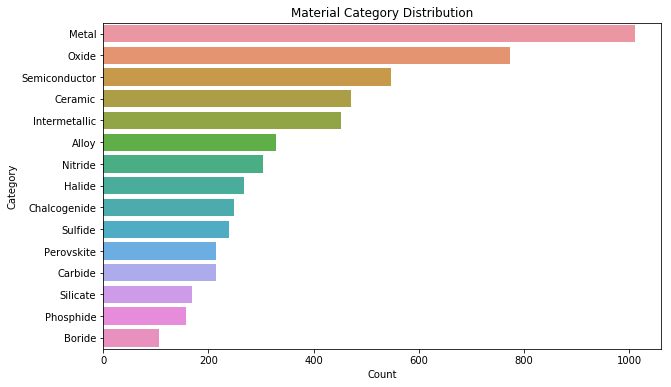

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(y='category',
              data=df,
              order=df['category'].value_counts().index)

plt.title("Material Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

Crystal System Distribution


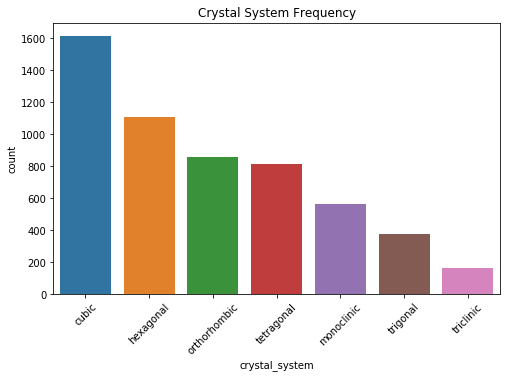

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
x='crystal_system',
data=df,
order=df['crystal_system'].value_counts().index)

plt.title("Crystal System Frequency")
plt.xticks(rotation=45)
plt.show()

Band Gap Distribution


c:\program files\python37\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\program files\python37\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\program files\python37\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


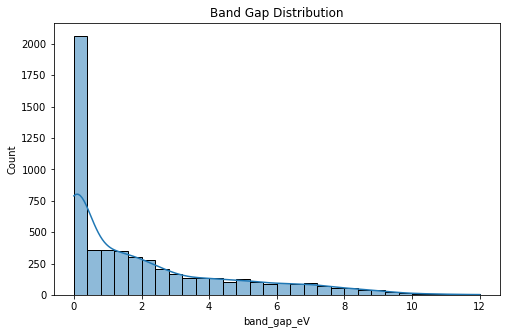

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['band_gap_eV'],
             bins=30,
             kde=True)

plt.title("Band Gap Distribution")
plt.show()

Stable vs Unstable Materials


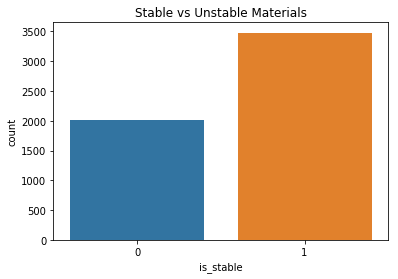

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_stable', data=df)

plt.title("Stable vs Unstable Materials")
plt.show()

Metal vs Non-Metal Distribution


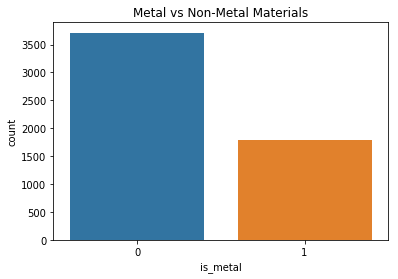

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_metal', data=df)

plt.title("Metal vs Non-Metal Materials")
plt.show()

Correlation Heatmap


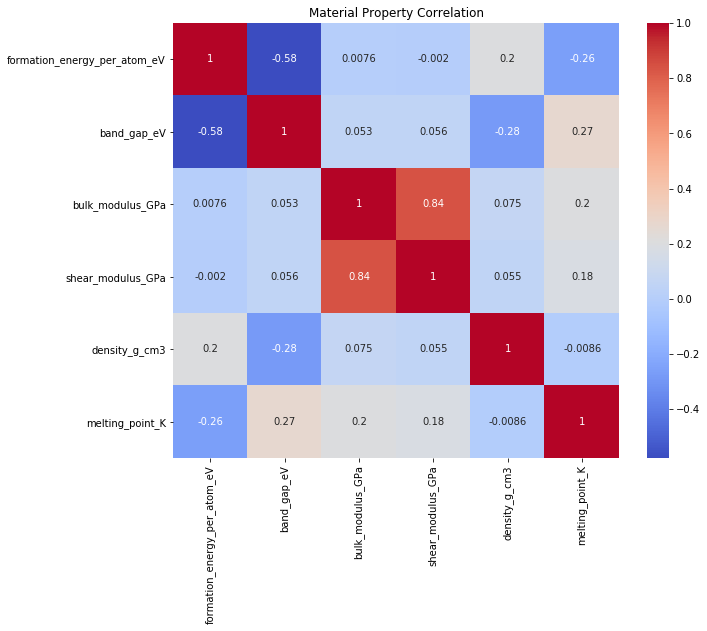

In [26]:
cols=[
'formation_energy_per_atom_eV',
'band_gap_eV',
'bulk_modulus_GPa',
'shear_modulus_GPa',
'density_g_cm3',
'melting_point_K'
]

plt.figure(figsize=(10,8))

sns.heatmap(
df[cols].corr(),
annot=True,
cmap='coolwarm')

plt.title("Material Property Correlation")
plt.show()

Density by Material Category


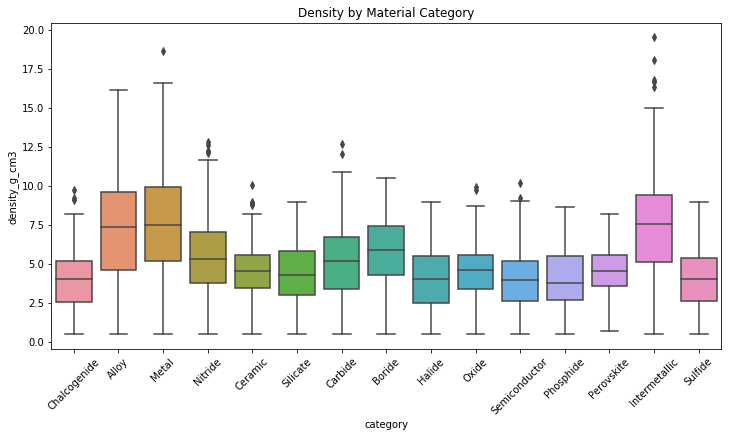

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
x='category',
y='density_g_cm3',
data=df)

plt.xticks(rotation=45)
plt.title("Density by Material Category")
plt.show()

Melting Point by Category


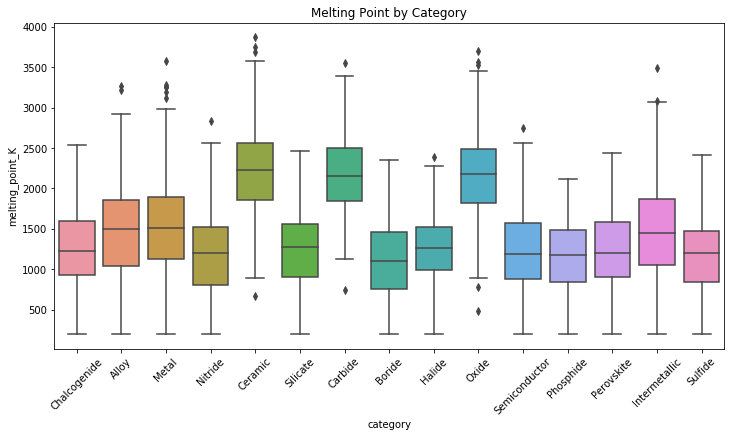

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
x='category',
y='melting_point_K',
data=df)

plt.xticks(rotation=45)

plt.title("Melting Point by Category")
plt.show()

Bulk Modulus vs Shear Modulus


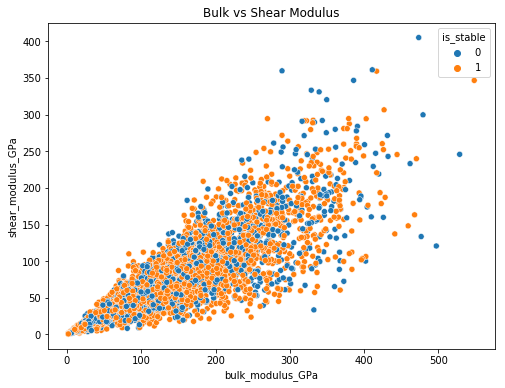

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x='bulk_modulus_GPa',
y='shear_modulus_GPa',
hue='is_stable',
data=df)

plt.title("Bulk vs Shear Modulus")
plt.show()

Formation Energy vs Stability


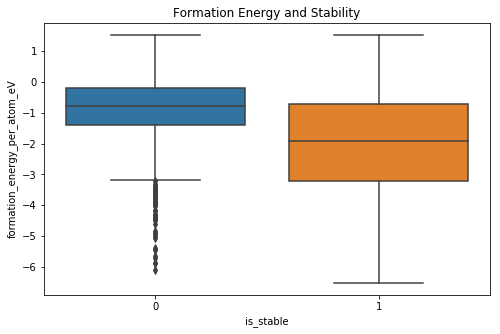

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
x='is_stable',
y='formation_energy_per_atom_eV',
data=df)

plt.title("Formation Energy and Stability")
plt.show()

Band Gap of Stable vs Unstable Materials


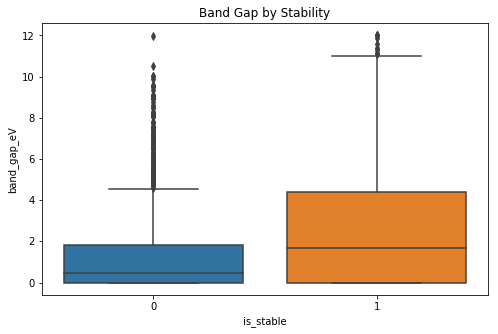

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
x='is_stable',
y='band_gap_eV',
data=df)

plt.title("Band Gap by Stability")
plt.show()

Top 15 Strongest Engineering Materials


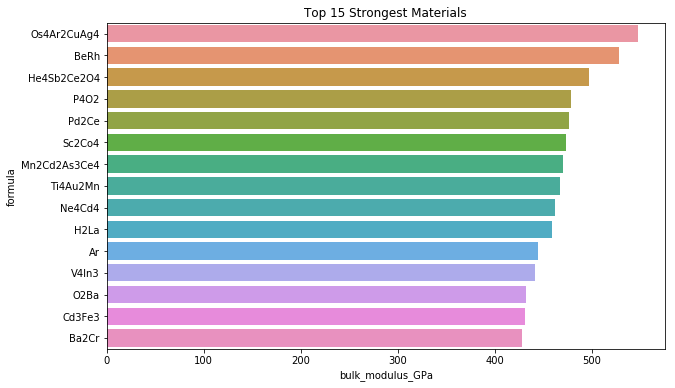

In [32]:
top15 = df.sort_values(
'bulk_modulus_GPa',
ascending=False).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
x='bulk_modulus_GPa',
y='formula',
data=top15)

plt.title("Top 15 Strongest Materials")
plt.show()

Risk Score Visualization 

c:\program files\python37\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\program files\python37\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\program files\python37\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


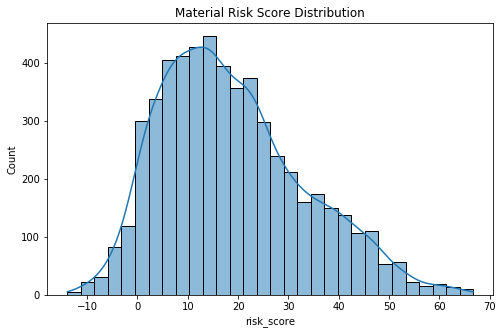

In [33]:
df['risk_score'] = (
df['energy_above_hull_eV']*50
-
df['formation_energy_per_atom_eV']*10
)

plt.figure(figsize=(8,5))

sns.histplot(
df['risk_score'],
bins=30,
kde=True)

plt.title("Material Risk Score Distribution")
plt.show()